<a href="https://colab.research.google.com/github/strzelnat/studia-ml/blob/main/life_expectancy_ml_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import seaborn as sns
import warnings

In [2]:
warnings.filterwarnings('ignore')

In [4]:
df = pd.read_csv('/content/Life Expectancy Data.csv')
df.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [5]:
df.columns

Index(['Country', 'Year', 'Status', 'Life expectancy ', 'Adult Mortality',
       'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B',
       'Measles ', ' BMI ', 'under-five deaths ', 'Polio', 'Total expenditure',
       'Diphtheria ', ' HIV/AIDS', 'GDP', 'Population',
       ' thinness  1-19 years', ' thinness 5-9 years',
       'Income composition of resources', 'Schooling'],
      dtype='object')

In [6]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)

summary = pd.DataFrame(
    {
        'dtype': df.dtypes,
        'missing_value': missing,
        'missing_pct': missing_pct
    }
).sort_values('missing_pct', ascending=False)

summary

,dtype,missing_value,missing_pct
Population,float64,652,22.2
Hepatitis B,float64,553,18.8
GDP,float64,448,15.2
Total expenditure,float64,226,7.7
Alcohol,float64,194,6.6
Income composition of resources,float64,167,5.7
Schooling,float64,163,5.5
thinness 1-19 years,float64,34,1.2
thinness 5-9 years,float64,34,1.2
BMI,float64,34,1.2


In [7]:
from sklearn.preprocessing import LabelEncoder

df_model = df.copy()

In [8]:
TARGET = 'Life expectancy '
df_model.dropna(subset=[TARGET], inplace=True)
df_model.drop(columns=['Country'], inplace = True)
df_model['Status'] = LabelEncoder().fit_transform(df_model['Status'])

In [9]:
X = df_model.drop(columns=[TARGET])
y = df_model[TARGET]

print(f'Próbki: {len(y)}')
print(f'Cechy:  {X.shape[1]}')
print(f'\nCechy: {list(X.columns)}')
print(f'\nCel — min: {y.min():.1f}, max: {y.max():.1f}, mean: {y.mean():.1f}')

Próbki: 2928
Cechy:  20

Cechy: ['Year', 'Status', 'Adult Mortality', 'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B', 'Measles ', ' BMI ', 'under-five deaths ', 'Polio', 'Total expenditure', 'Diphtheria ', ' HIV/AIDS', 'GDP', 'Population', ' thinness  1-19 years', ' thinness 5-9 years', 'Income composition of resources', 'Schooling']

Cel — min: 36.3, max: 89.0, mean: 69.2


In [10]:
df_model.head()

,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,2015,1,65.0,263.0,62,0.01,71.279624,65.0,1154,19.1,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,2014,1,59.9,271.0,64,0.01,73.523582,62.0,492,18.6,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,2013,1,59.9,268.0,66,0.01,73.219243,64.0,430,18.1,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,2012,1,59.5,272.0,69,0.01,78.184215,67.0,2787,17.6,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,2011,1,59.2,275.0,71,0.01,7.097109,68.0,3013,17.2,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [11]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

def pipeline_standard(model):
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),   # mean=0, std=1
        ('model', model)
    ])

def pipeline_minmax(model):
  return Pipeline([
      ('imputer', SimpleImputer(strategy='median')), #[0-1] normalization
      ('scaler', MinMaxScaler()),
      ('model', model)
  ])

def pipeline_none(model):
  return Pipeline([
      ('imputer',SimpleImputer(strategy = 'median')),
      ('model', model)
  ])

In [12]:
PIPELINES = {'Standaryzacja' : pipeline_standard, 'Normalizacja': pipeline_minmax, 'Brak skalowania': pipeline_none}

In [13]:
from sklearn.model_selection import KFold

In [14]:
kfold = KFold(n_splits=5, shuffle=True, random_state=42) #shuffle miesza wiersze przed podzialem

In [15]:
results = []

In [16]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor, AdaBoostRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import cross_val_score, KFold
import xgboost as xgb
import lightgbm as lgb
from time import time

In [17]:
MODELS = {
    'Linear Regression':  LinearRegression(),
    'Ridge':              Ridge(),
    'Lasso':              Lasso(),
    'ElasticNet':         ElasticNet(),
    'KNN':                KNeighborsRegressor(),
    'Decision Tree':      DecisionTreeRegressor(),
    'Random Forest':      RandomForestRegressor(n_jobs=-1),
    'Extra Trees':        ExtraTreesRegressor(n_jobs=-1),
    'Gradient Boosting':  GradientBoostingRegressor(),
    'AdaBoost':           AdaBoostRegressor(),
    'XGBoost':            xgb.XGBRegressor(verbosity=0, n_jobs=-1),
    'LightGBM':           lgb.LGBMRegressor(verbose=-1, n_jobs=-1),
}

In [18]:
PIPELINES.items()

dict_items([('Standaryzacja', <function pipeline_standard at 0x7acbb0eed9e0>), ('Normalizacja', <function pipeline_minmax at 0x7acba599e2a0>), ('Brak skalowania', <function pipeline_none at 0x7acba56bda80>)])

In [19]:
MODELS.items()

dict_items([('Linear Regression', LinearRegression()), ('Ridge', Ridge()), ('Lasso', Lasso()), ('ElasticNet', ElasticNet()), ('KNN', KNeighborsRegressor()), ('Decision Tree', DecisionTreeRegressor()), ('Random Forest', RandomForestRegressor(n_jobs=-1)), ('Extra Trees', ExtraTreesRegressor(n_jobs=-1)), ('Gradient Boosting', GradientBoostingRegressor()), ('AdaBoost', AdaBoostRegressor()), ('XGBoost', XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=No

In [20]:
from sklearn.model_selection import train_test_split

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'X_train: {X_train.shape}')
print(f'X_test:  {X_test.shape}')
print(f'y_train: {y_train.shape}')
print(f'y_test:  {y_test.shape}')

X_train: (2342, 20)
X_test:  (586, 20)
y_train: (2342,)
y_test:  (586,)


In [22]:
for pipe_name, make_pipe in PIPELINES.items():
  for model_name, model in MODELS.items():
    pipe = make_pipe(model)
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    rmse = mean_squared_error(y_test, y_pred) ** 0.5
    mae = mean_absolute_error(y_test, y_pred)

    cv = cross_val_score(pipe, X_train, y_train, cv = kfold, scoring = 'r2', n_jobs = -1)

    results.append({
            'Pipeline':   pipe_name,
            'Model':      model_name,
            'R²':         round(r2, 4),
            'RMSE':       round(rmse, 4),
            'MAE':        round(mae, 4),
            'CV R² mean': round(cv.mean(), 4),
            'CV R² std':  round(cv.std(), 4),
            'pipe_obj':   pipe
        })

results_df = pd.DataFrame(results)


In [23]:
results_df.sort_values('RMSE')

,Pipeline,Model,R²,RMSE,MAE,CV R² mean,CV R² std,pipe_obj
19,Normalizacja,Extra Trees,0.9711,1.5798,0.9022,0.9656,0.0037,"(SimpleImputer(strategy='median'), MinMaxScale..."
31,Brak skalowania,Extra Trees,0.9707,1.5911,0.9090,0.9651,0.0036,"(SimpleImputer(strategy='median'), (ExtraTreeR..."
7,Standaryzacja,Extra Trees,0.9704,1.5999,0.9249,0.9657,0.0038,"(SimpleImputer(strategy='median'), StandardSca..."
11,Standaryzacja,LightGBM,0.9667,1.6967,1.1176,0.9593,0.0042,"(SimpleImputer(strategy='median'), StandardSca..."
6,Standaryzacja,Random Forest,0.9666,1.7000,1.0708,0.9576,0.0040,"(SimpleImputer(strategy='median'), StandardSca..."
18,Normalizacja,Random Forest,0.9663,1.7073,1.0775,0.9568,0.0040,"(SimpleImputer(strategy='median'), MinMaxScale..."
35,Brak skalowania,LightGBM,0.9661,1.7130,1.1350,0.9595,0.0042,"(SimpleImputer(strategy='median'), LGBMRegress..."
30,Brak skalowania,Random Forest,0.9660,1.7149,1.0743,0.9574,0.0043,"(SimpleImputer(strategy='median'), (DecisionTr..."
22,Normalizacja,XGBoost,0.9657,1.7234,1.1484,0.9551,0.0015,"(SimpleImputer(strategy='median'), MinMaxScale..."
10,Standaryzacja,XGBoost,0.9657,1.7234,1.1484,0.9551,0.0015,"(SimpleImputer(strategy='median'), StandardSca..."


In [24]:
best_pipeline = pipeline_minmax(ExtraTreesRegressor(n_jobs=-1))

In [25]:
param_grid = {
    'model__n_estimators':      [100, 200, 300, 500, 700, 1000],
    'model__max_depth':         [None, 10, 20, 30, 50],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf':  [1, 2, 4],
    'model__max_features':      ['sqrt', 'log2', 0.5, 0.7, 1.0],
}

In [26]:
from sklearn.model_selection import RandomizedSearchCV

In [27]:
search = RandomizedSearchCV(
    estimator=best_pipeline,
    param_distributions=param_grid,
    n_iter=50,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    verbose=2
)

In [28]:
search.fit(X_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('imputer',
                                              SimpleImputer(strategy='median')),
                                             ('scaler', MinMaxScaler()),
                                             ('model',
                                              ExtraTreesRegressor(n_jobs=-1))]),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'model__max_depth': [None, 10, 20, 30,
                                                             50],
                                        'model__max_features': ['sqrt', 'log2',
                                                                0.5, 0.7, 1.0],
                                        'model__min_samples_leaf': [1, 2, 4],
                                        'model__min_samples_split': [2, 5, 10],
                                        'model__n_estimators': [100, 200, 300,
                                                                500, 700,
                                                                1000]},
                   random_state=42, scoring='r2', verbose=2)

In [29]:
print(f'\nNajlepsze parametry:')
for k, v in search.best_params_.items():
  print(f' {k}: {v}')
print(f'\nNajlepszy CV R²: {search.best_score_:.4f}')


Najlepsze parametry:
 model__n_estimators: 500
 model__min_samples_split: 2
 model__min_samples_leaf: 1
 model__max_features: 1.0
 model__max_depth: 30

Najlepszy CV R²: 0.9669


In [30]:
y_pred = search.predict(X_test)

In [33]:
model_results = pd.DataFrame(
    {
        'real_values': y_test,
        'predict_values': y_pred,
        'differance': abs(y_test - y_pred)
    }
)

model_results.head(15)

,real_values,predict_values,differance
2399,56.5,56.3738,0.1262
196,73.0,69.8426,3.1574
2316,82.5,82.5652,0.0652
1735,75.6,75.9214,0.3214
1102,53.0,53.2702,0.2702
1194,65.2,65.1420,0.0580
1507,72.4,73.4164,1.0164
1161,74.1,74.0276,0.0724
322,77.0,76.2896,0.7104
1352,67.8,67.8802,0.0802


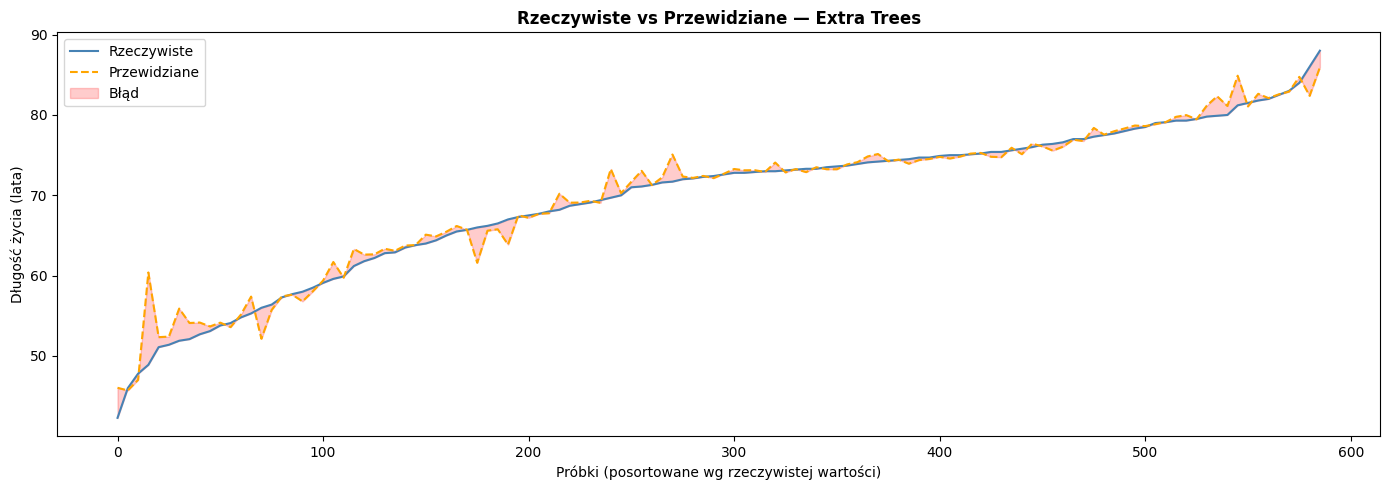

In [37]:
plot_df = model_results.sort_values('real_values').reset_index(drop=True)

plot_df = plot_df.iloc[::5] # co 5 punkt - czytelniejszy wykres

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(plot_df.index, plot_df['real_values'],    color='steelblue', linewidth=1.5, label='Rzeczywiste')
ax.plot(plot_df.index, plot_df['predict_values'], color='orange',    linewidth=1.5, label='Przewidziane', linestyle='--')

ax.fill_between(plot_df.index,
                plot_df['real_values'],
                plot_df['predict_values'],
                alpha=0.2, color='red', label='Błąd')

ax.set_xlabel('Próbki (posortowane wg rzeczywistej wartości)')
ax.set_ylabel('Długość życia (lata)')
ax.set_title('Rzeczywiste vs Przewidziane — Extra Trees', fontweight='bold')
ax.legend()

plt.tight_layout()
plt.show()

In [58]:
best_model = results_df[
    (results_df['Model'] == 'Extra Trees') &
    (results_df['Pipeline'] == 'Normalizacja')
].iloc[0]['pipe_obj'].named_steps['model']

best_model

ExtraTreesRegressor(n_jobs=-1)

In [59]:
importance_df = pd.DataFrame(
    {
        'Cecha': X.columns,
        'Ważność': best_model.feature_importances_
    }
).sort_values('Ważność', ascending = False)

In [60]:
importance_df

,Cecha,Ważność
2,Adult Mortality,0.258919
18,Income composition of resources,0.257859
13,HIV/AIDS,0.115255
19,Schooling,0.091524
8,BMI,0.082305
1,Status,0.040611
10,Polio,0.028392
16,thinness 1-19 years,0.023899
12,Diphtheria,0.023214
17,thinness 5-9 years,0.015624


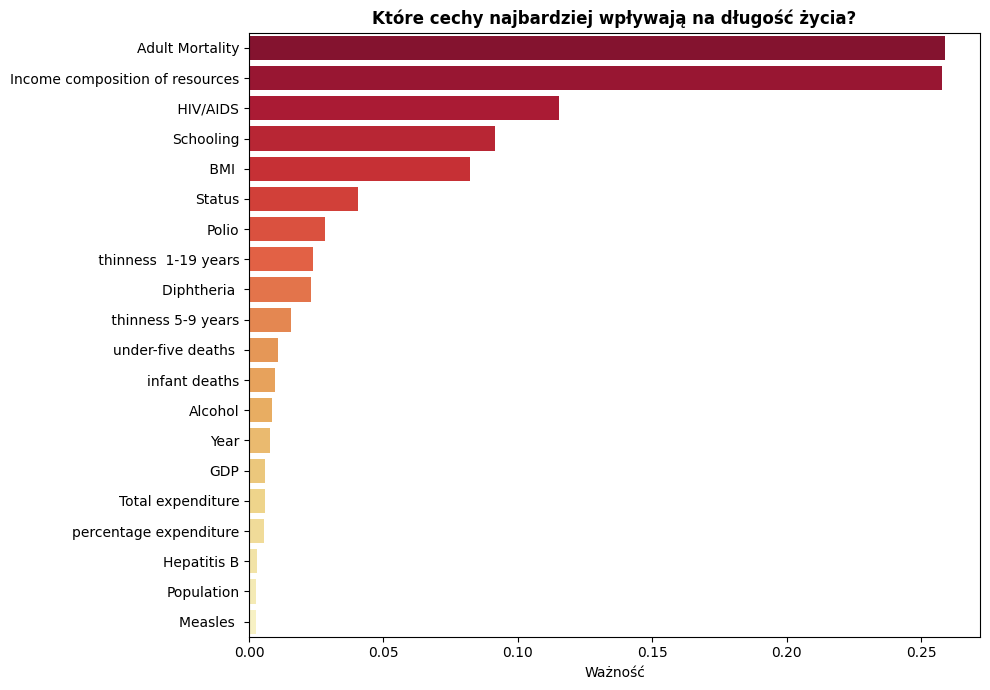

In [63]:
fig, ax = plt.subplots(figsize=(10, 7))

sns.barplot(data=importance_df, x='Ważność', y='Cecha', palette='YlOrRd_r', ax=ax)

ax.set_title('Które cechy najbardziej wpływają na długość życia?', fontweight='bold')
ax.set_xlabel('Ważność')
ax.set_ylabel('')

plt.tight_layout()
plt.show()